In [ ]:
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense, AveragePooling2D
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [ ]:
data = pd.read_csv(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data\Images32.csv')
data.head()

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p1014,p1015,p1016,p1017,p1018,p1019,p1020,p1021,p1022,p1023
0,0,234,235,222,165,209,240,227,219,225,...,99,106,107,111,112,28,105,117,114,111
1,0,247,245,240,178,190,206,238,237,234,...,215,210,206,203,188,22,201,194,192,188
2,0,147,140,106,47,6,139,138,138,137,...,48,17,18,75,90,29,11,117,110,104
3,0,194,193,183,134,194,197,198,198,199,...,73,69,77,68,66,65,68,72,69,67
4,0,205,202,203,205,208,209,210,208,209,...,188,162,207,203,190,193,199,191,191,187


In [ ]:
X = data.drop(columns=data.columns[0], axis=1)
Y = data[data.columns[0]]

In [ ]:
print(X.shape)
print(Y.shape)

(2483, 1024)
(2483,)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
X_train = X_train.values.reshape(1986, 32, 32, 1)
X_test = X_test.values.reshape(497, 32, 32, 1)

(1986, 1024)
(497, 1024)
(1986,)


In [ ]:
num_classes=3
Y_train=to_categorical(Y_train,num_classes)
Y_test=to_categorical(Y_test,num_classes)

In [ ]:
lenet = Sequential()
lenet.add(Conv2D(filters=6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 1)))
lenet.add(AveragePooling2D(pool_size=(2, 2), strides=2))
lenet.add(Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'))
lenet.add(AveragePooling2D(pool_size=(2, 2), strides=2))
lenet.add(Conv2D(filters=120, kernel_size=(5, 5), activation='tanh')) 
lenet.add(Flatten())
lenet.add(Dense(84, activation='tanh'))
lenet.add(Dense(3, activation='softmax'))        
lenet.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])
summary=lenet.summary()
summary=lenet.fit(X_train,Y_train,epochs=10,verbose=1,validation_data=(X_test,Y_test))
lenet.save('lenet_model.keras')

c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,111 (238.71 KB)

 Trainable params: 61,111 (238.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6012 - loss: 0.9343 - val_accuracy: 0.4406 - val_loss: 0.9574
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6073 - loss: 0.9110 - val_accuracy: 0.5433 - val_loss: 0.8916
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7442 - loss: 0.6781 - val_accuracy: 0.4024 - val_loss: 1.1649
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7664 - loss: 0.6180 - val_accuracy: 0.8511 - val_loss: 0.4667
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8540 - loss: 0.4161 - val_accuracy: 0.8592 - val_loss: 0.3754
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8640 - loss: 0.3741 - val_accuracy: 0.8873 - val_loss: 0.3203
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8938 - loss: 0.3085 - val_accuracy: 0.4326 - val_loss: 2.0410
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8993 - loss: 0.3024 - val_accuracy: 0.8813 - val_loss

In [ ]:
print("Training Accuracy = ",summary.history['accuracy'])
print("Testing Accuracy = ",summary.history['val_accuracy'])
print("Training Loss = ",summary.history['loss'])
print("Testing Loss = ",summary.history['val_loss'])

Training Accuracy =  [0.6012084484100342, 0.6072507500648499, 0.7442094683647156, 0.766364574432373, 0.8539778590202332, 0.8640483617782593, 0.8937562704086304, 0.8992950916290283, 0.9093655347824097, 0.9003021121025085]
Testing Accuracy =  [0.44064387679100037, 0.5432595610618591, 0.4024145007133484, 0.8511066436767578, 0.8591549396514893, 0.8873239159584045, 0.4325955808162689, 0.8812877535820007, 0.877263605594635, 0.895372211933136]
Training Loss =  [0.9343044757843018, 0.9109628796577454, 0.6781125664710999, 0.6180083155632019, 0.4160672426223755, 0.37406787276268005, 0.3085020184516907, 0.30236032605171204, 0.25723209977149963, 0.2984955310821533]
Testing Loss =  [0.9573891758918762, 0.8916245102882385, 1.1648650169372559, 0.4667419493198395, 0.3753807544708252, 0.3202749192714691, 2.0410213470458984, 0.3264388144016266, 0.3136063516139984, 0.3006555140018463]


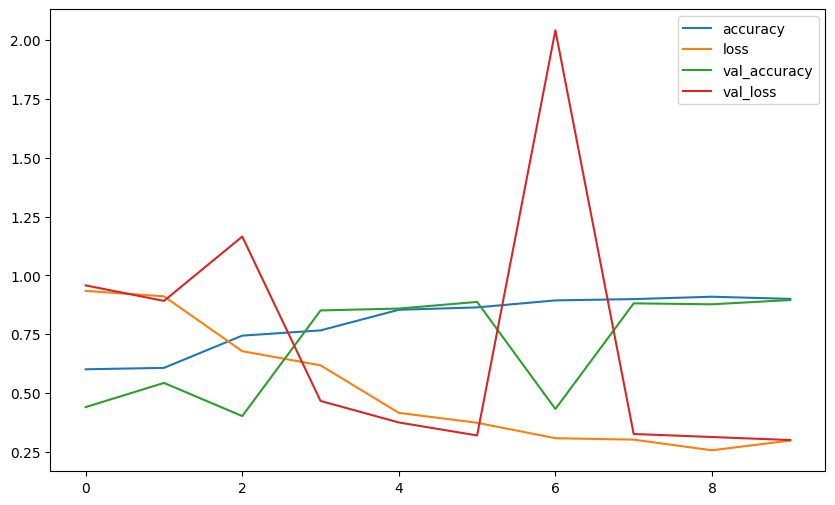

In [ ]:
pd.DataFrame(summary.history).plot(figsize=(10,6))
plt.show()